# Create single G1 model

**Goal:**
Create a model that uses the same G1 for mother and daughter cells. The daughter cells will have a different time interval, but the constructed H should use the same columns for both mothers and daughters. The config and/or the calcH will need to be modified.


**Notes:**
- Retrieiving indices and timepoints by phase and branch will need to be changed for DG1
    - The indices will match CG1
    - The timepoints will be from the config
    

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


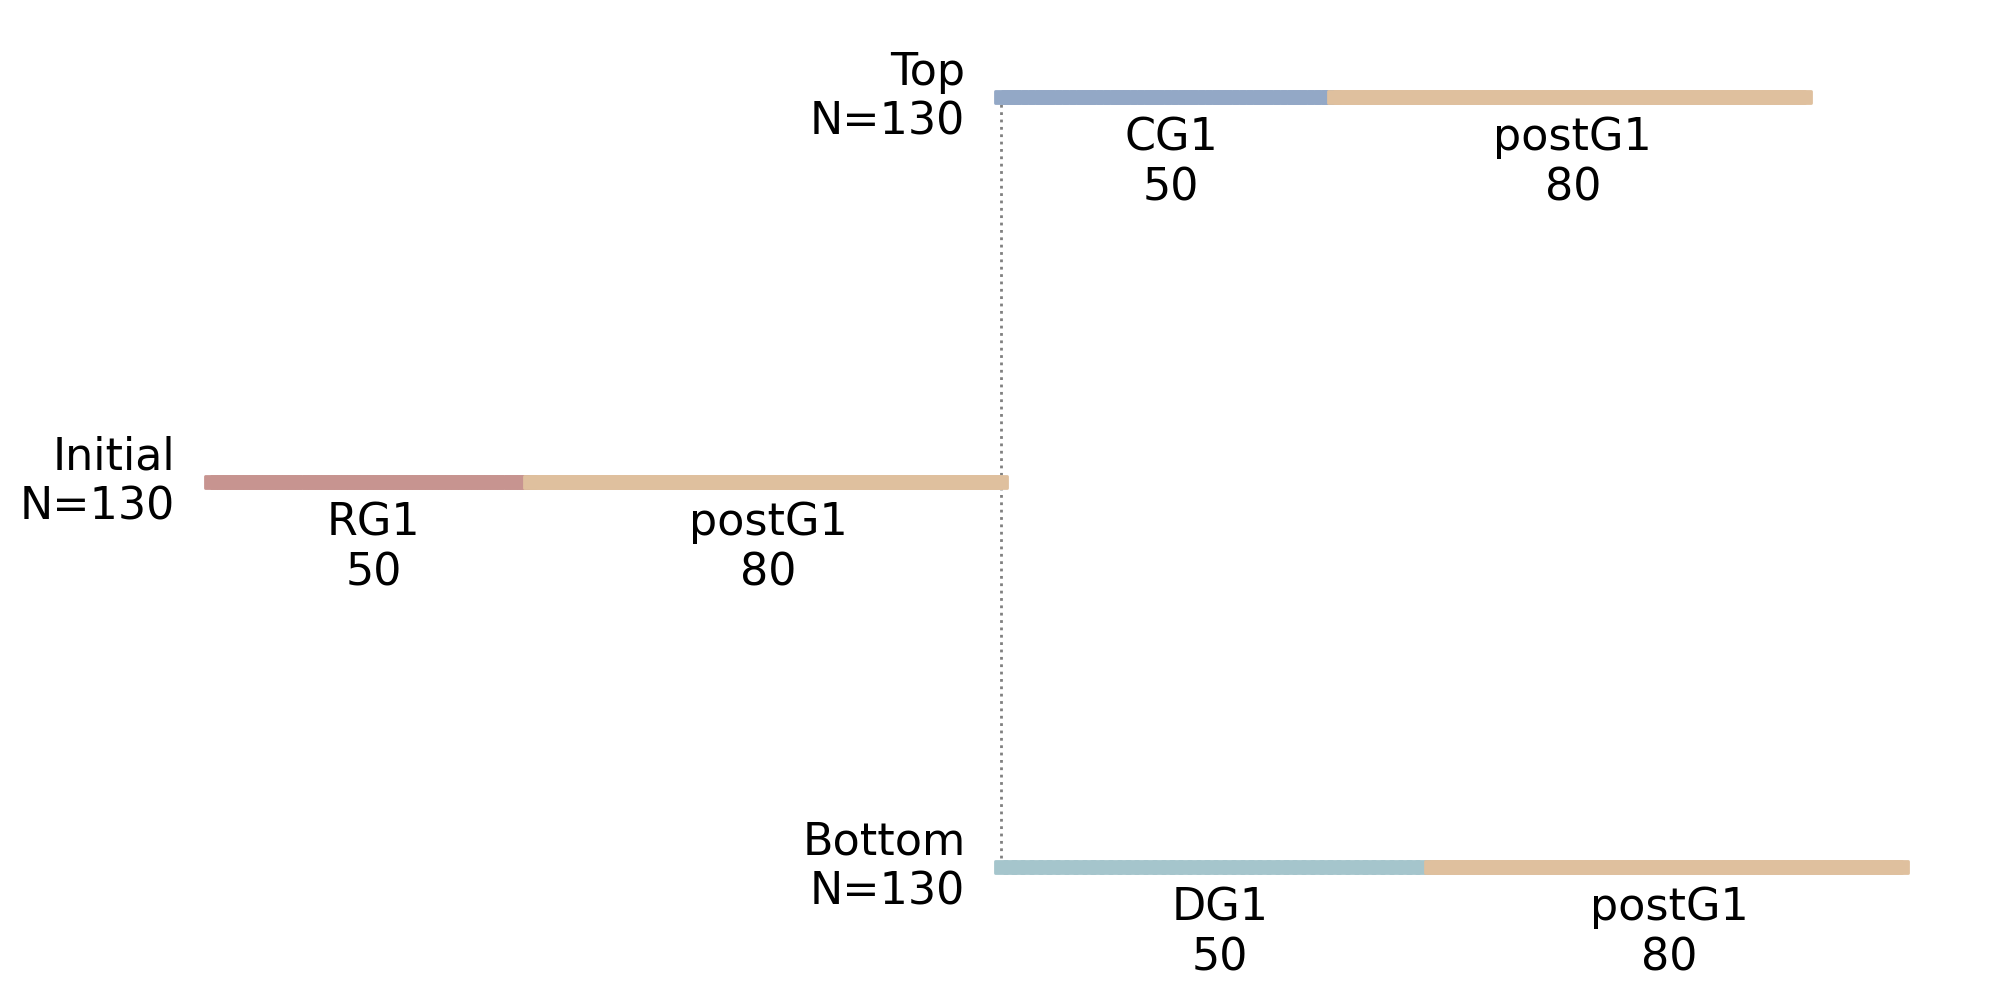

In [88]:
from src.calcH_single_g1 import calcH
from src.single_G1_config import load_single_g1_config

config1 = load_single_g1_config(1)
H, Hpositions = calcH(config1.intervals_wt1, config1.WT1_TIMEPOINTS)

In [125]:
from src.model import Model

model = Model(config1, 'CLB2')

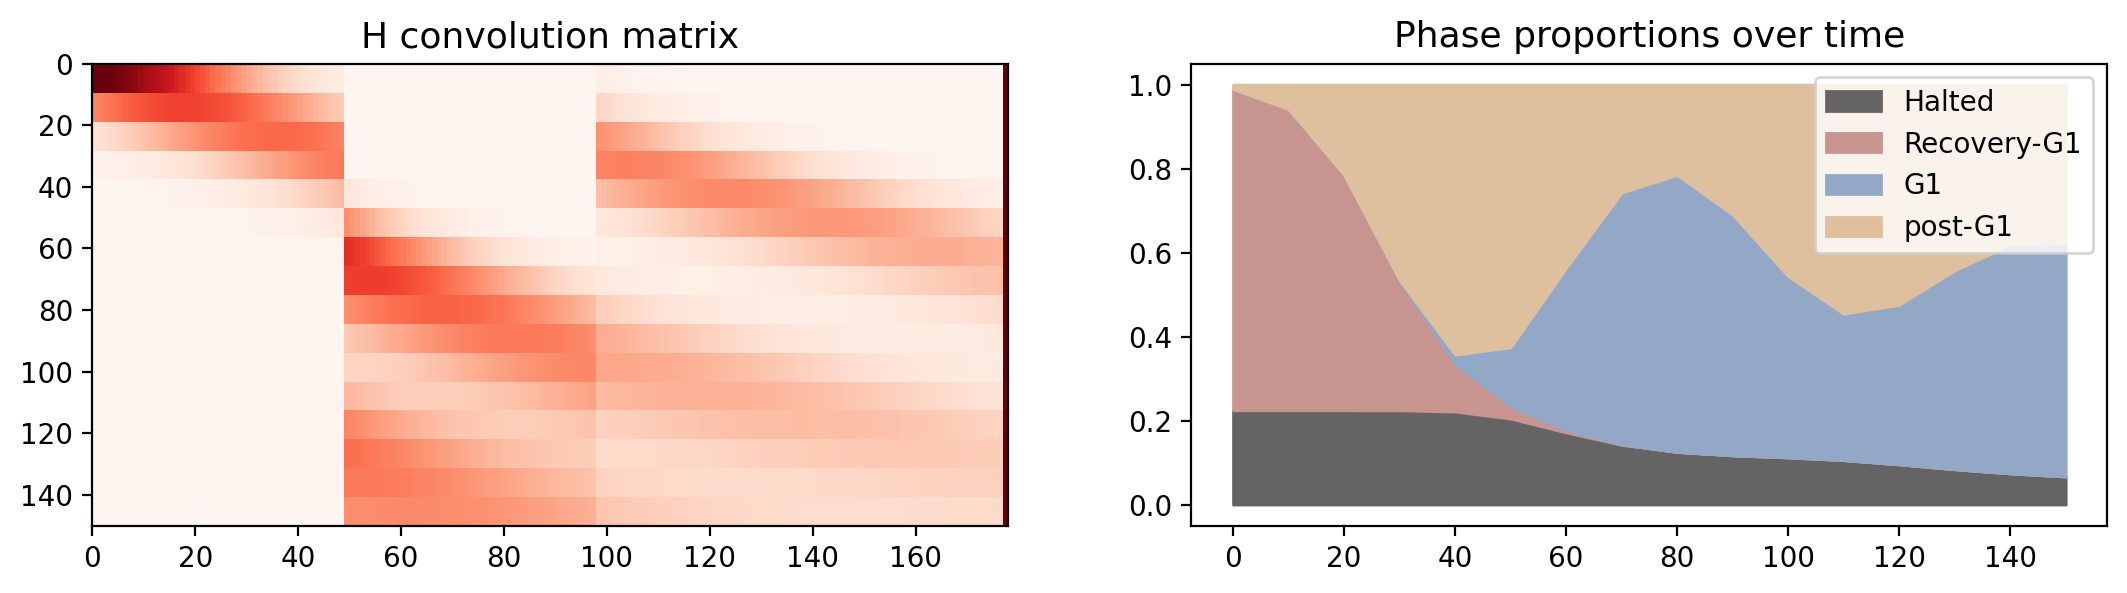

In [128]:
from src.single_G1_config import plot_H

plot_H(model.config, model.H)

In [132]:
model.deconvolve_find_optimal_gamma()

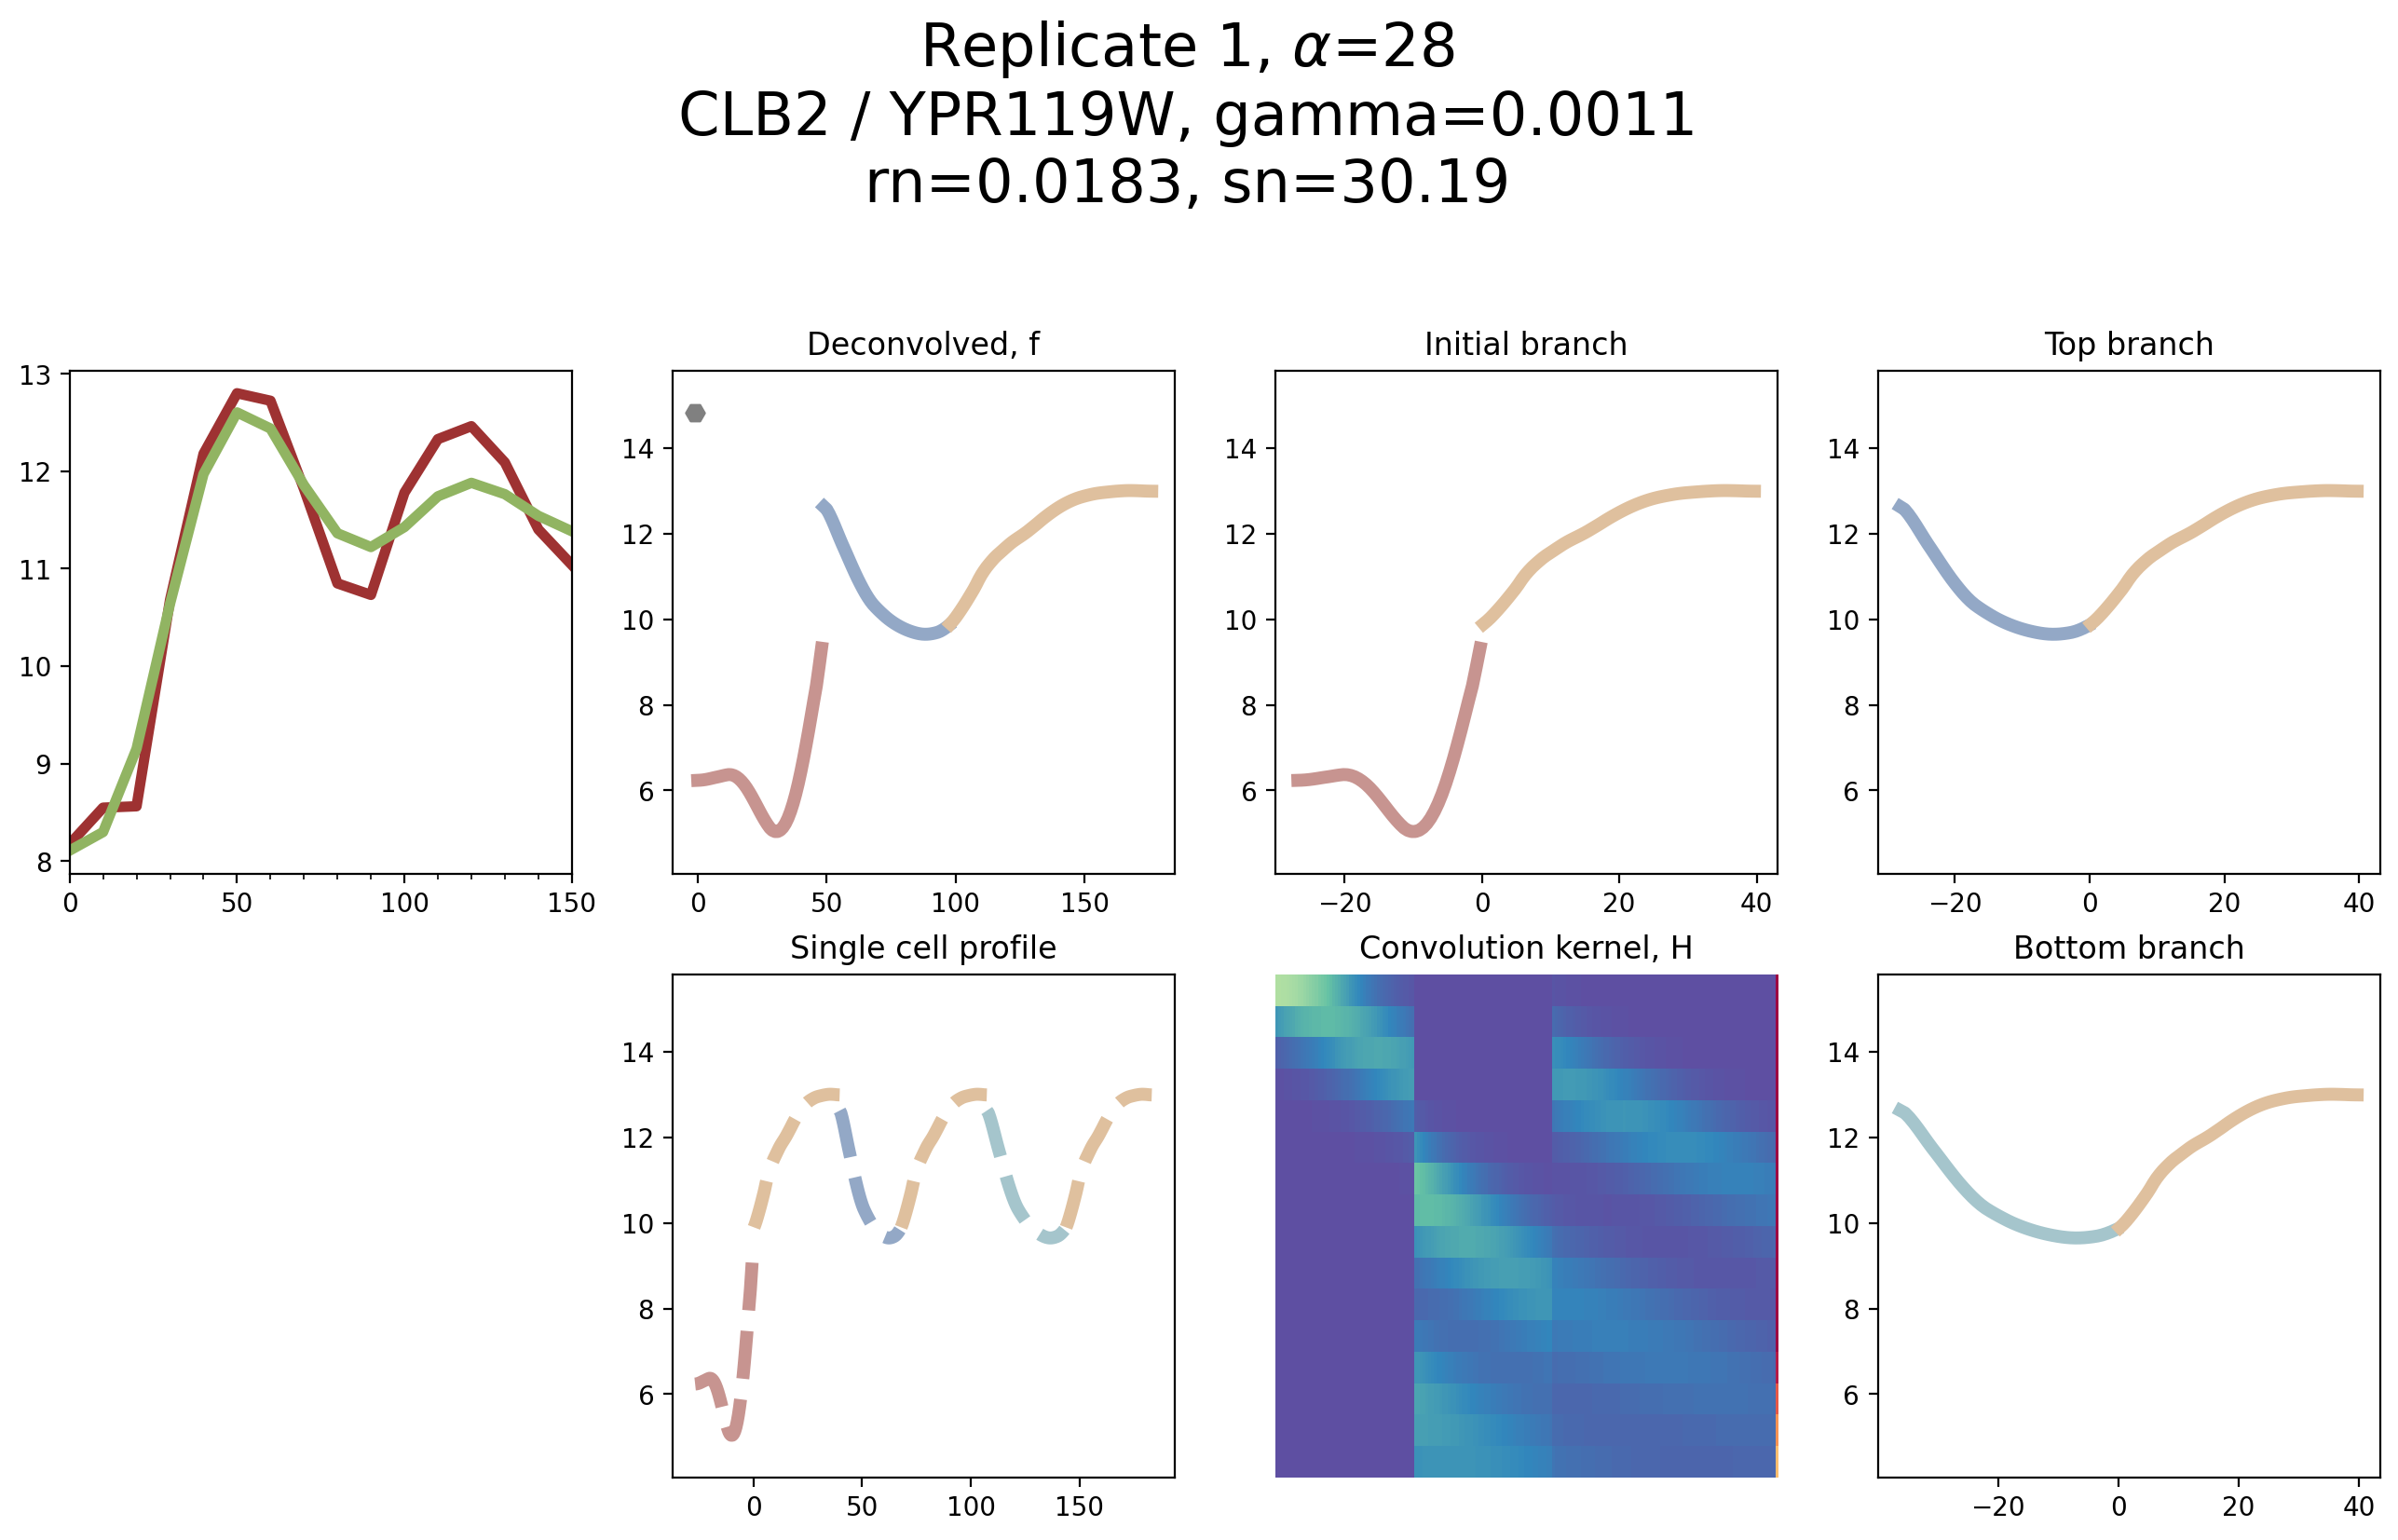

In [134]:
fig = model.plot_deconvolved_gene()

In [135]:
from src.chromatin_model import ChromatinModel

chrom_model = ChromatinModel(config1)
chrom_model.load_mnase_gene('CLB2')

Loading MNase reads for YPR119W/CLB2...Loading chromosome reads: 16
Done.


In [136]:
chrom_model.create_deconvolution_bins()

In [138]:
chrom_model.deconvolve(0.008)

Deconvolving with gamma=0.006
0/340 - 00:00:00.133
100/340 - 00:00:10.660
200/340 - 00:00:21.185
300/340 - 00:00:32.457
Deconvolved in : 00:00:38.070
The fitting norm is 6.26, the smoothing norm is: 36.78


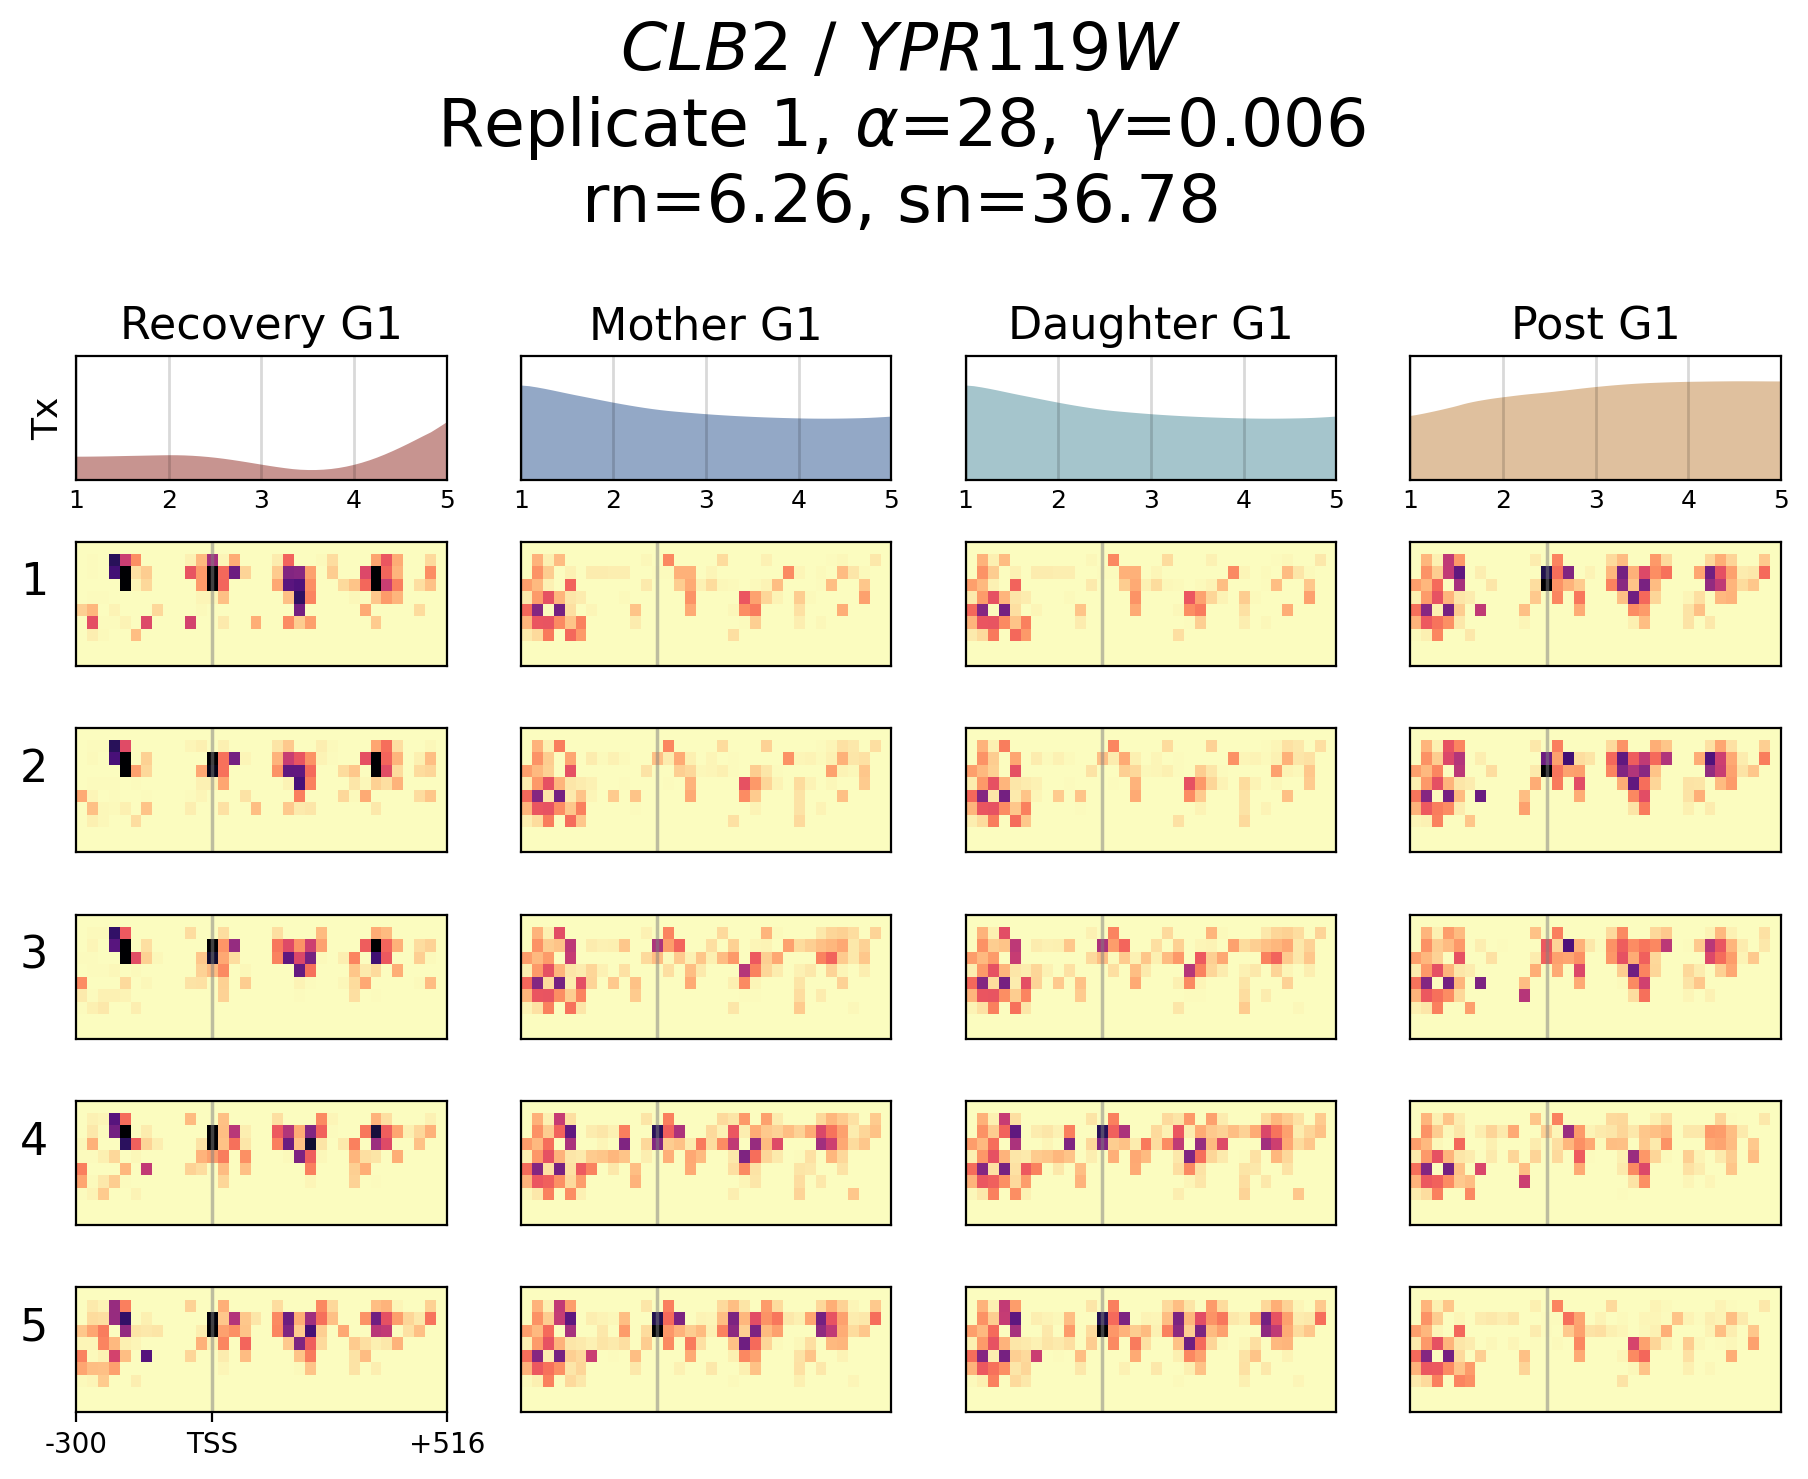

In [140]:
fig = chrom_model.create_deconvolution_plots_abbreviated_flipped(vmax=30, ge_model=model)

Loading MNase reads for YER124C/DSE1...Loading chromosome reads: 5
Done.
Loading MNase reads for YER124C/DSE1...Loading chromosome reads: 5
Done.
Deconvolving combined model with gamma=0.008
Deconvolving bin size: 24x24
of G shape: (31, 340)
Deconvolving with gamma=0.008
0/340 - 00:00:00.131
100/340 - 00:00:11.256
200/340 - 00:00:21.985
300/340 - 00:00:32.839
Deconvolved in : 00:00:38.503
The fitting norm is 14.01, the smoothing norm is: 22.56


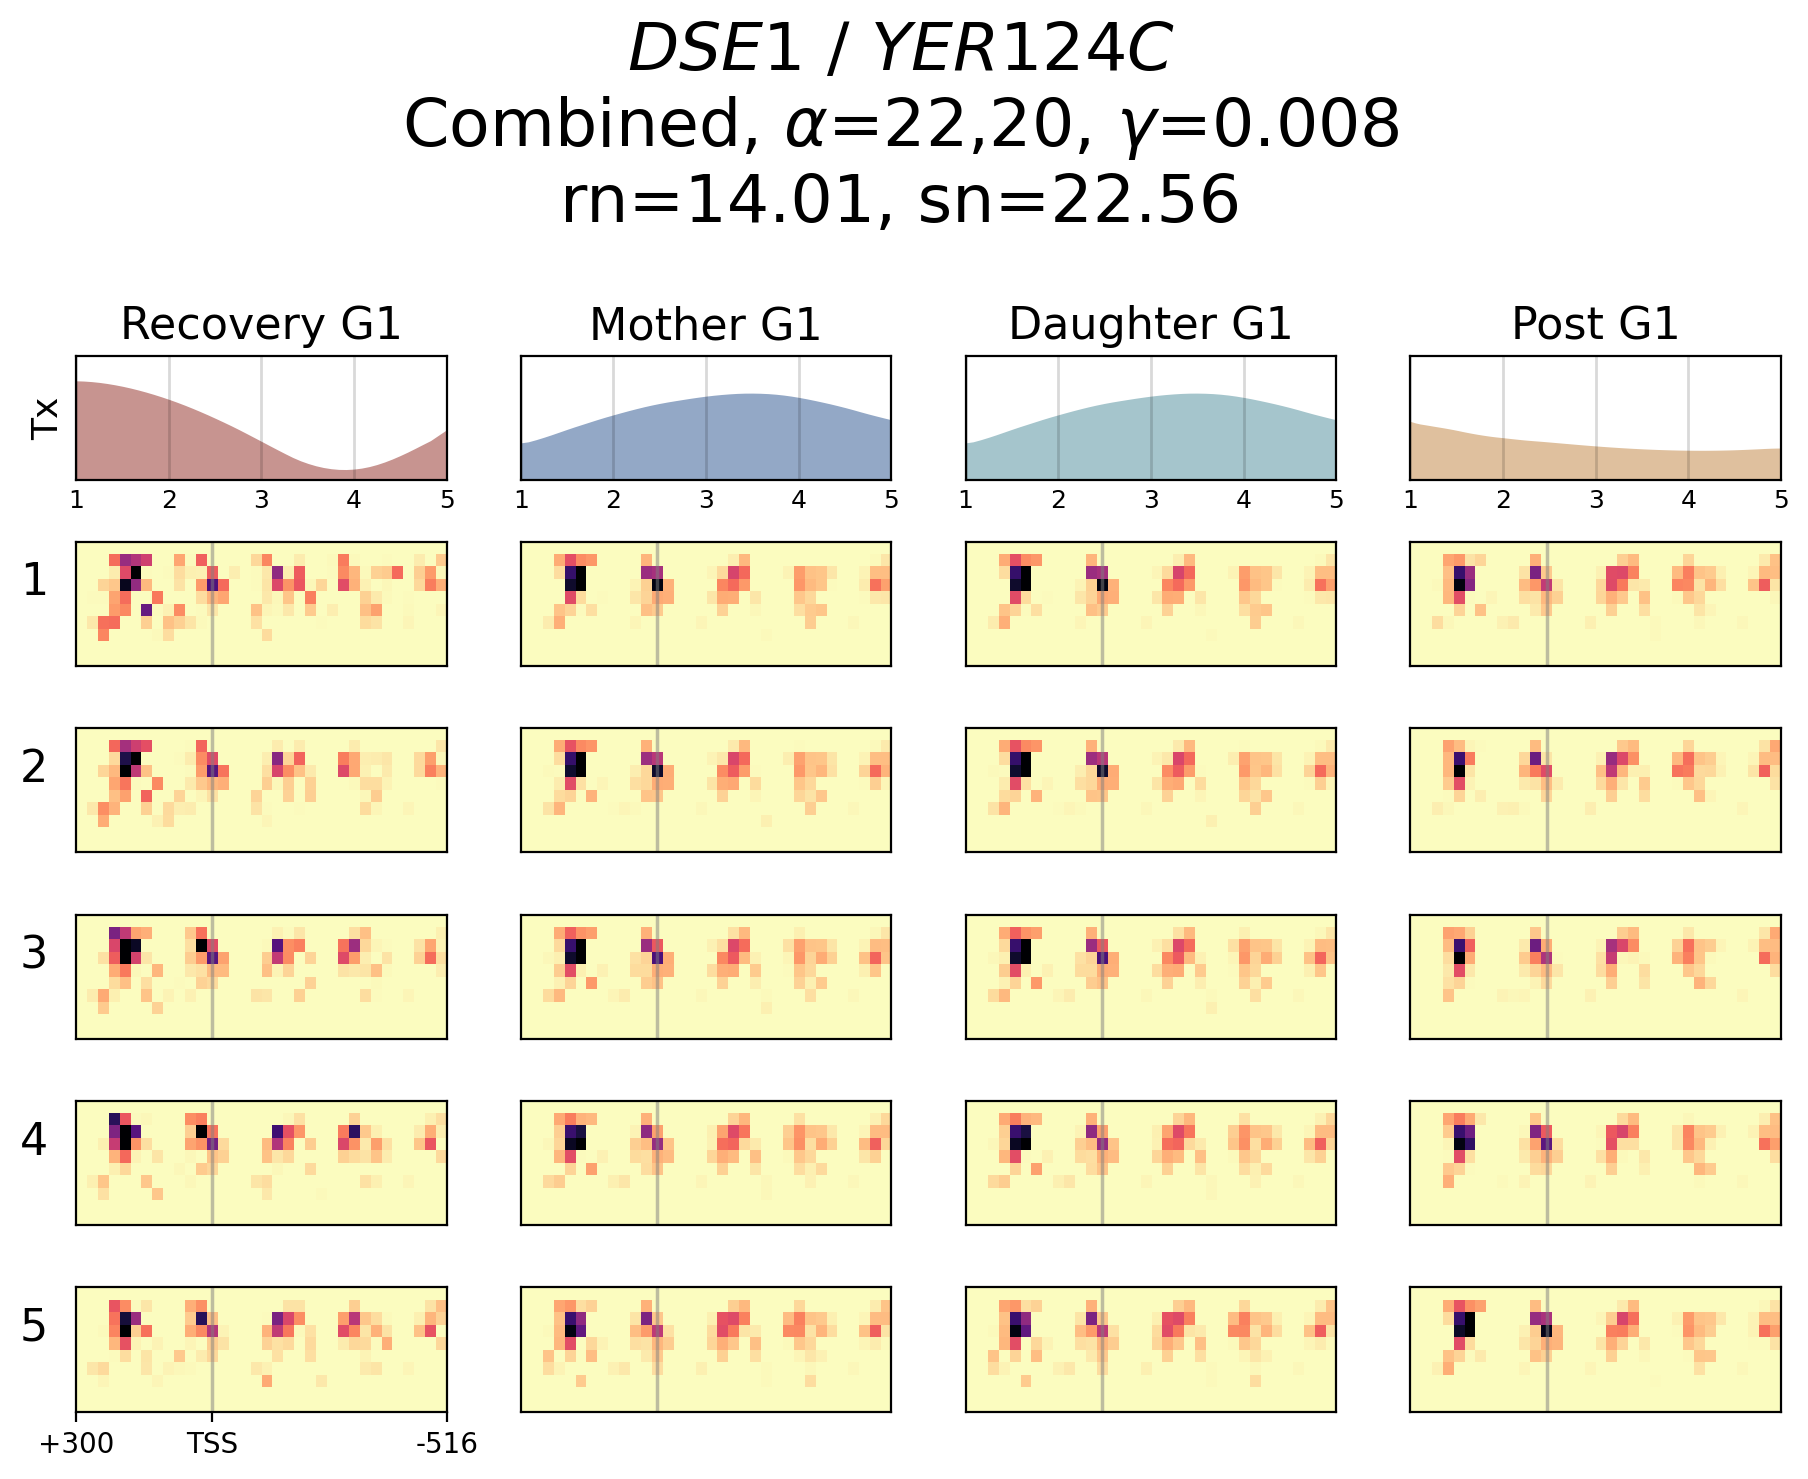

In [188]:
gene_name = "DSE1"

ge_config = load_combined_single_g1_gene_expression_config()
ge_model = Model(ge_config, gene_name)
ge_model.deconvolve_find_optimal_gamma()

combined_model.load_combined_mnase_gene(gene_name)
combined_model.deconvolve(gamma=0.008)
fig = combined_model.create_deconvolution_plots_abbreviated_flipped(ge_model=ge_model)

Loading MNase reads for YPR119W/CLB2...Already loaded chromosome reads for 16. Using cache.
Done.
Loading MNase reads for YPR119W/CLB2...Already loaded chromosome reads for 16. Using cache.
Done.
Deconvolving combined model with gamma=0.008
Deconvolving bin size: 24x24
of G shape: (31, 340)
Deconvolving with gamma=0.008
0/340 - 00:00:00.128
100/340 - 00:00:12.223
200/340 - 00:00:23.935
300/340 - 00:00:36.617
Deconvolved in : 00:00:42.238
The fitting norm is 13.73, the smoothing norm is: 32.91


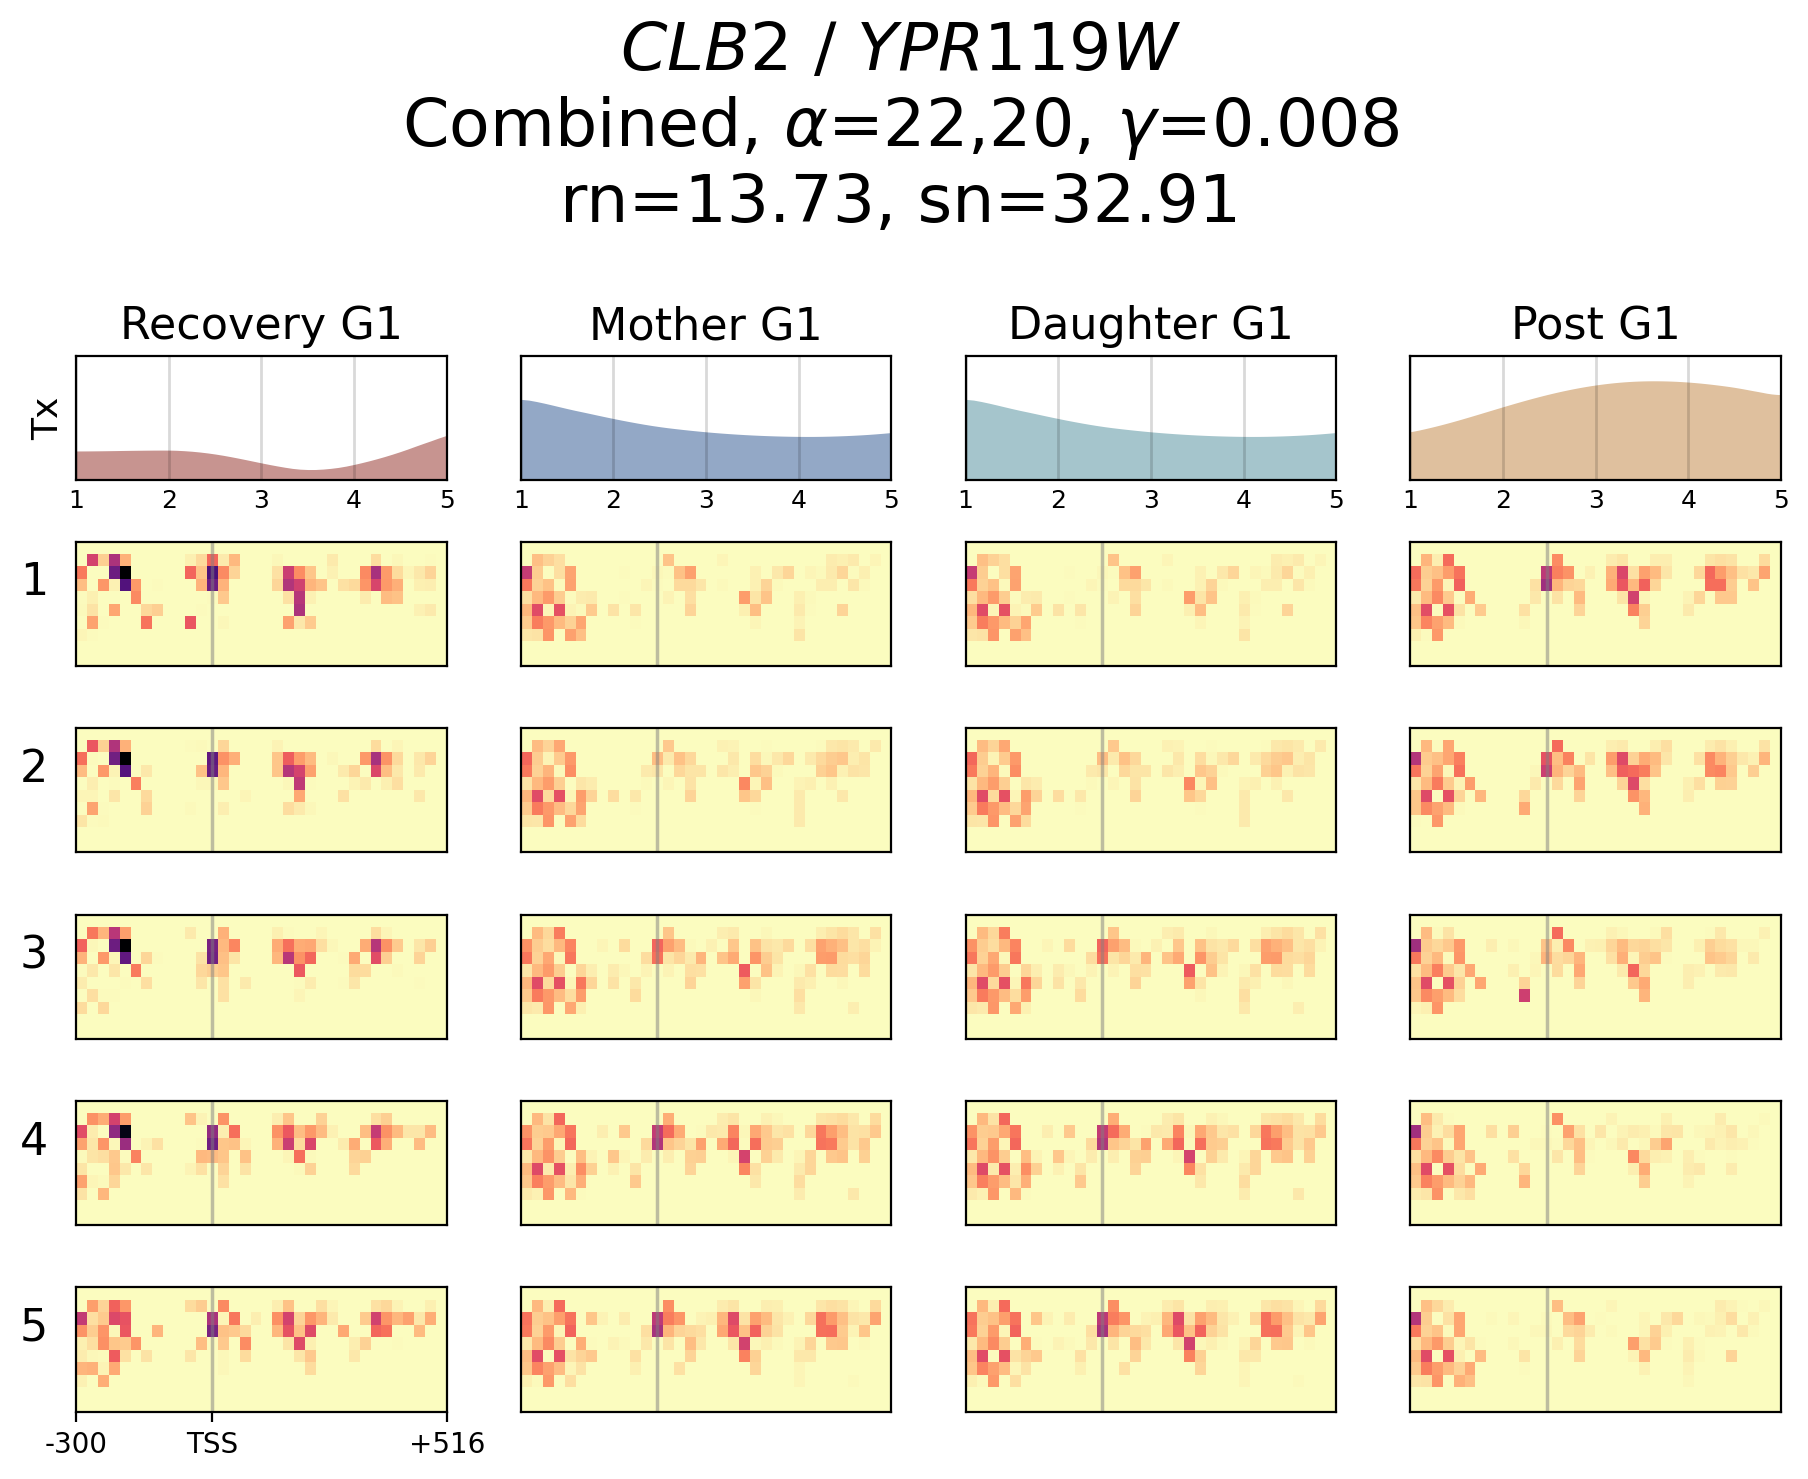

In [187]:
gene_name = "CLB2"

ge_config = load_combined_single_g1_gene_expression_config()
ge_model = Model(ge_config, gene_name)
ge_model.deconvolve_find_optimal_gamma()

combined_model.load_combined_mnase_gene(gene_name)
combined_model.deconvolve(gamma=0.008)
fig = combined_model.create_deconvolution_plots_abbreviated_flipped(ge_model=ge_model)